<a href="https://colab.research.google.com/github/harifaly/EDA_TRAINING/blob/main/Titanic_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [85]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [86]:
print("Shape :", df.shape)

Shape : (891, 12)


In [87]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Valeur manquant

In [88]:
# _____analyse de valeur manquant_______
manquants=df.isnull().sum()
print(manquants)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


<Axes: >

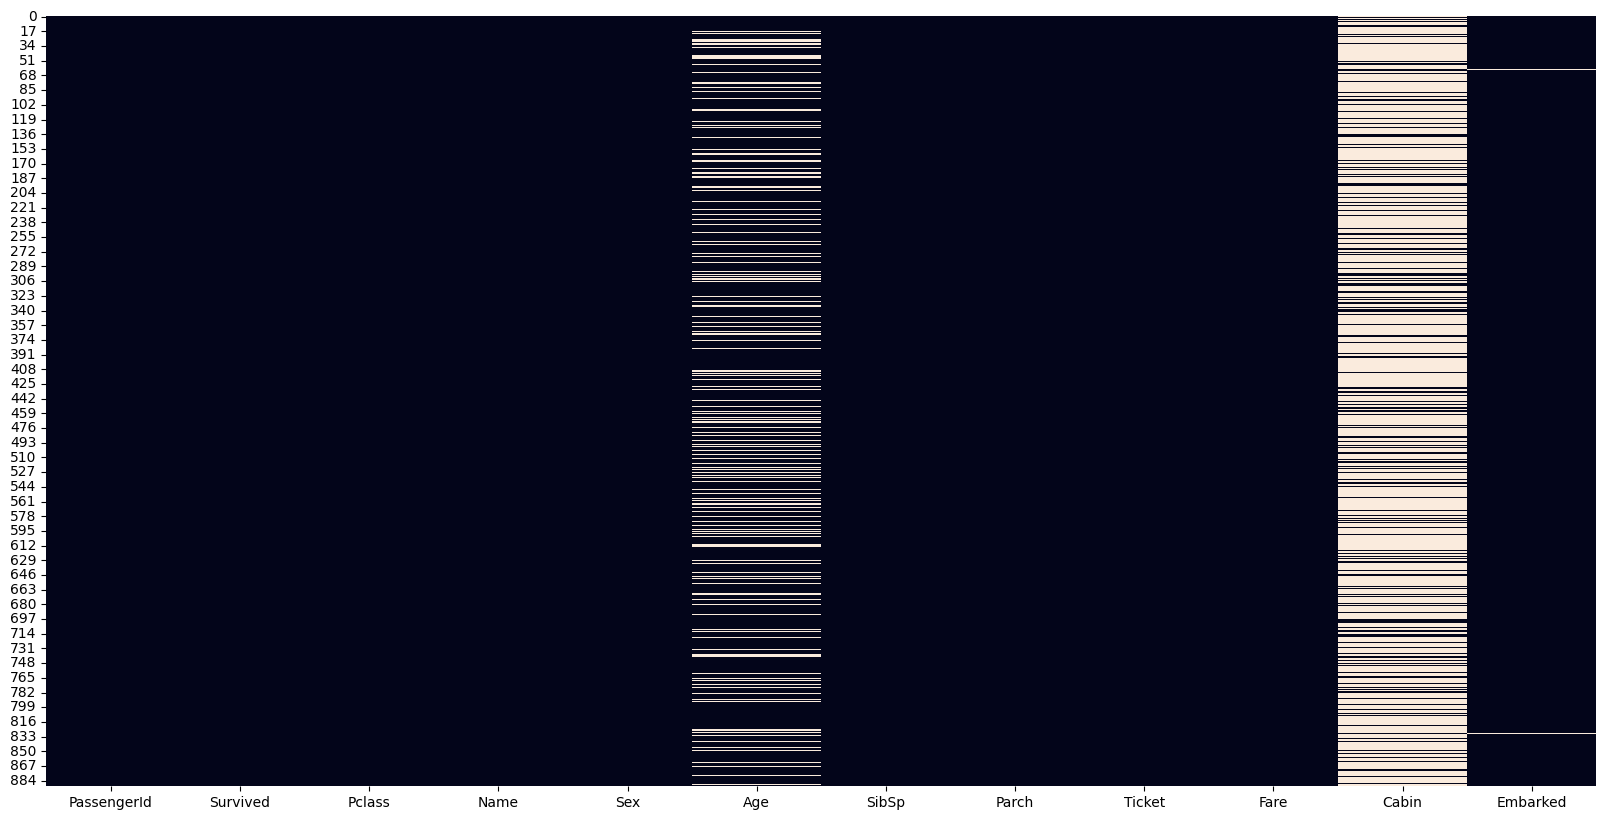

In [89]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(),cbar=False)

In [90]:
manquants_pct = (manquants / len(df) * 100).round(1)  # ccalcul la Calcul du pourcentage de valeurs manquantes
# len(df): nbr de ligne
# round(1):arrondi a 1 chiffre apres virgule

In [91]:
manquants_df = pd.DataFrame({'count': manquants, 'pct': manquants_pct})
# creation d un dataframe resume pour nos dataframe et les valeurs manquantes

In [92]:
print("\nValeurs manquantes :")
print(manquants_df)


Valeurs manquantes :
             count   pct
PassengerId      0   0.0
Survived         0   0.0
Pclass           0   0.0
Name             0   0.0
Sex              0   0.0
Age            177  19.9
SibSp            0   0.0
Parch            0   0.0
Ticket           0   0.0
Fare             0   0.0
Cabin          687  77.1
Embarked         2   0.2


In [93]:
manquants_df = manquants_df[manquants_df['count'] > 0].sort_values('pct', ascending=False)
# On garde seulement les collones qui ont au moin un valeur manquants

In [94]:
print("\nValeurs manquantes :")
print(manquants_df)


Valeurs manquantes :
          count   pct
Cabin       687  77.1
Age         177  19.9
Embarked      2   0.2


Nettoyage

In [95]:
# _______Nettoyage_____
# Dans la colonne age :ramplacons les NaN par la mediane
df['Age'] = df['Age'].fillna(df['Age'].median())

In [96]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [97]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [98]:
#Supprimons les colonnes non necessaire(ou trop de val manquant)
df=df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])

In [99]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [100]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [101]:
df.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True


visualisation

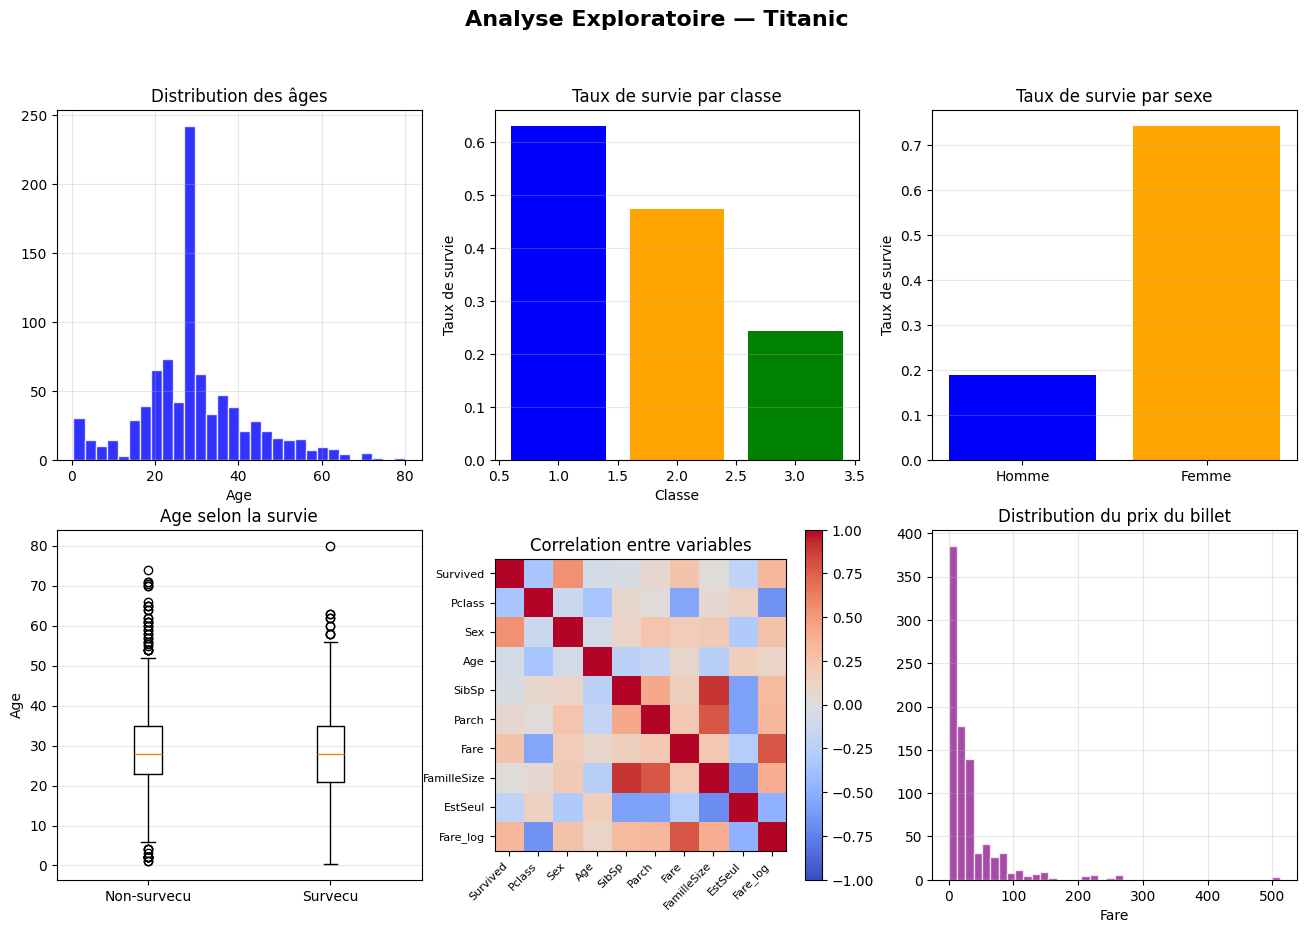

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Analyse Exploratoire — Titanic', fontsize=16, fontweight='bold')

# _____Distribution de l'age_______
axes[0,0].hist(df['Age'], bins=30, color='blue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Distribution des âges')
axes[0,0].set_xlabel('Age')
axes[0,0].grid(True, alpha=0.3)




# _______Survie par classe________
survie_classe = df.groupby('Pclass')['Survived'].mean()
axes[0,1].bar(survie_classe.index, survie_classe.values, color=['blue','orange','green'])
axes[0,1].set_title('Taux de survie par classe')
axes[0,1].set_xlabel('Classe')
axes[0,1].set_ylabel('Taux de survie')
axes[0,1].grid(True, alpha=0.3, axis='y')


# ____Survie par sexe_______
survie_sexe = df.groupby('Sex')['Survived'].mean()
axes[0,2].bar(['Homme', 'Femme'], survie_sexe.values, color=['blue', 'orange'])
axes[0,2].set_title('Taux de survie par sexe')
axes[0,2].set_ylabel('Taux de survie')
axes[0,2].grid(True, alpha=0.3, axis='y')

#_____Boxplot age vs survie_____
survived = df[df['Survived'] == 1]['Age']
not_survived = df[df['Survived'] == 0]['Age']
axes[1,0].boxplot([not_survived, survived], tick_labels=['Non-survecu', 'Survecu'])
axes[1,0].set_title('Age selon la survie')
axes[1,0].set_ylabel('Age')
axes[1,0].grid(True, alpha=0.3, axis='y')



# ______Heatmap de correlation________
num_cols = df.select_dtypes(include=np.number)
corr = num_cols.corr()
im = axes[1,1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(corr.columns)))
axes[1,1].set_yticks(range(len(corr.columns)))
axes[1,1].set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
axes[1,1].set_yticklabels(corr.columns, fontsize=8)
axes[1,1].set_title('Correlation entre variables')
plt.colorbar(im, ax=axes[1,1])



#_______Distribution du prix du billet_______
axes[1,2].hist(df['Fare'], bins=40, color='purple', edgecolor='white', alpha=0.7)
axes[1,2].set_title('Distribution du prix du billet')
axes[1,2].set_xlabel('Fare')
axes[1,2].grid(True, alpha=0.3)

In [102]:
# ______-feature engeneer______
df['FamilleSize'] = df['SibSp'] + df['Parch'] + 1

In [103]:
df['EstSeul'] = (df['FamilleSize'] == 1).astype(int)

In [104]:
df['Fare_log'] = np.log1p(df['Fare'])   # log transform pour réduire le skew

In [105]:
# _______Ptit resume de notre resultat______
print(f"Taux de survie global : {df['Survived'].mean():.1%}")
print(f"Taux survie 1ere classe : {df[df['Pclass']==1]['Survived'].mean():.1%}")
print(f"Taux survie 3eme classe : {df[df['Pclass']==3]['Survived'].mean():.1%}")
print(f"Taux survie femmes : {df[df['Sex']==1]['Survived'].mean():.1%}")
print(f"Taux survie hommes : {df[df['Sex']==0]['Survived'].mean():.1%}")

Taux de survie global : 38.4%
Taux survie 1ere classe : 63.0%
Taux survie 3eme classe : 24.2%
Taux survie femmes : 74.2%
Taux survie hommes : 18.9%


In [106]:
#  Test statistique : la différence de survie H/F est-elle significative ?
t_stat, p_value = stats.ttest_ind(
    df[df['Sex']==1]['Survived'],
    df[df['Sex']==0]['Survived']
)

In [107]:
print(f"\nTest t (survie homme vs femme) : p-value = {p_value:.2e}")


Test t (survie homme vs femme) : p-value = 1.41e-69


In [108]:
if p_value < 0.05:
    print("il y a de difference significative")
else:
    print("Pas significatif.")

il y a de difference significative
